# Substack sample check

Looking at the frozen sample in `substack-sampled-final-2026-10-02-with-likes-comments.zip`. The window is January 2020 through 17 September 2026. We treat December 2022 as the break, since that's the first full month after ChatGPT opened to the public.

Started from the monthly coverage table (648 topic-month rows) and the 81 monthly manifests. Later cells use the creator-month files and `posts_meta` from the same zip. The 4.43 GB shard and the Medium snapshot are a separate collection, so they're left out of this notebook.


In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

candidates = [
    Path("data/substack_eda"),
    Path("../data/substack_eda"),
    Path("/Users/kofibadu/Desktop/cap folder/data/substack_eda"),
]
DATA = next(p for p in candidates if (p / "monthly_coverage.csv").exists())

coverage = pd.read_csv(DATA / "monthly_coverage.csv")
manifests = pd.read_csv(DATA / "monthly_manifests.csv")
coverage["year_month"] = pd.to_datetime(coverage["year_month"] + "-01")
manifests["month"] = pd.to_datetime(manifests["month"] + "-01")
CUT = pd.Timestamp("2022-12-01")

for col in ["eligible_candidate_creators", "sampled_creators", "topic_floor_target", "topic_floor_shortfall", "pending_publications"]:
    coverage[col] = pd.to_numeric(coverage[col])

print(f"coverage rows: {len(coverage):,}   months: {manifests['month'].nunique()}")
print(f"every month passed validation: {bool(manifests['validation_passed'].all())}")
print(f"pending publications on every coverage row: {sorted(coverage['pending_publications'].unique())}")


coverage rows: 648   months: 81
every month passed validation: True
pending publications on every coverage row: [np.int64(37314)]


## Who made it in

The draw is capped at 2,500 creators a month, and a creator only counts if they posted something public that month. January and February 2020 come in under the cap. There just weren't 2,500 eligible people yet.


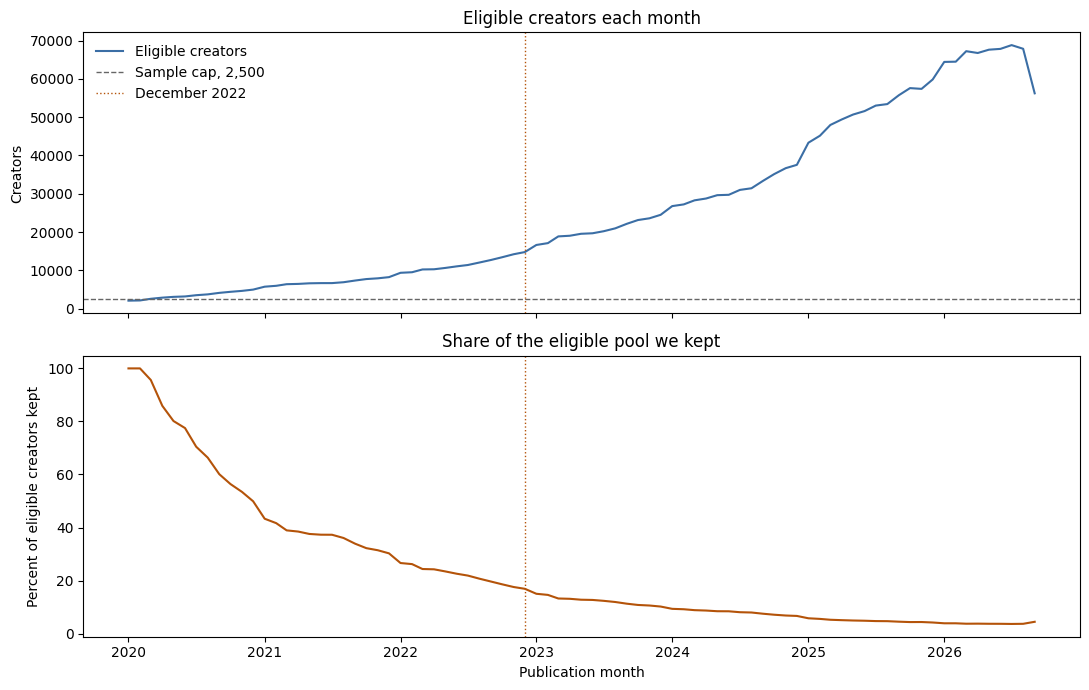

,year_month,eligible,sampled,kept_pct
0,2020-01,2128,2128,100.000000
34,2022-11,14237,2500,17.559879
35,2022-12,14802,2500,16.889610
78,2026-07,68800,2500,3.633721
80,2026-09,56221,2500,4.446737


In [25]:
month = (
    coverage.groupby("year_month", as_index=False)
    .agg(eligible=("eligible_candidate_creators", "sum"), sampled=("sampled_creators", "sum"))
)
month["kept_pct"] = 100 * month["sampled"] / month["eligible"]
manifests = manifests.merge(
    month.rename(columns={"year_month": "month"}),
    on="month",
    how="left",
)
manifests["posts_per_creator"] = manifests["unique_selected_texts"] / manifests["creator_months"]
manifests["period"] = manifests["month"].ge(CUT).map({False: "pre", True: "post"})

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(month["year_month"], month["eligible"], color="#3b6ea5", label="Eligible creators")
axes[0].axhline(2500, color="#666666", ls="--", lw=1, label="Sample cap, 2,500")
axes[0].axvline(CUT, color="#b45309", ls=":", lw=1, label="December 2022")
axes[0].set_ylabel("Creators")
axes[0].set_title("Eligible creators each month")
axes[0].legend(frameon=False, loc="upper left")

axes[1].plot(month["year_month"], month["kept_pct"], color="#b45309")
axes[1].axvline(CUT, color="#b45309", ls=":", lw=1)
axes[1].set_ylabel("Percent of eligible creators kept")
axes[1].set_xlabel("Publication month")
axes[1].set_title("Share of the eligible pool we kept")
fig.tight_layout()
plt.show()

checkpoints = month[month["year_month"].isin(pd.to_datetime(["2020-01-01", "2022-11-01", "2022-12-01", "2026-07-01", "2026-09-01"]))]
checkpoints.assign(year_month=checkpoints["year_month"].dt.strftime("%Y-%m"))


## Posts we kept

Each creator contributes 1 to 3 public posts in a month. That's why the monthly total sits near 5,100 the whole way through. If people started publishing more often after ChatGPT, this file won't show it.


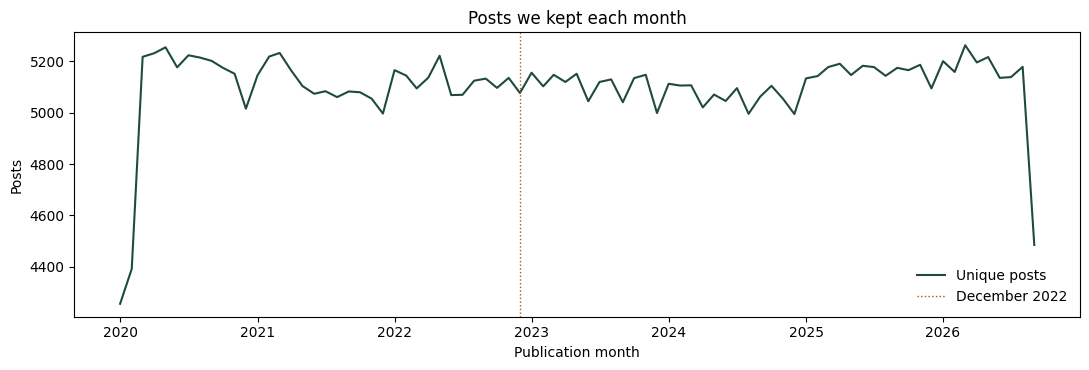

creator-months: 201,810
unique posts: 413,252
assignment rows, including coauthors: 414,898
extra coauthor links: 1,646
posts per creator-month: 2.048
pre  mean posts/month: 5092 over 35 months
post mean posts/month: 5110 over 46 months
partial month: ['2026-09']


In [26]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(manifests["month"], manifests["unique_selected_texts"], color="#1f4b3a", label="Unique posts")
ax.axvline(CUT, color="#b45309", ls=":", lw=1, label="December 2022")
ax.set_ylabel("Posts")
ax.set_xlabel("Publication month")
ax.set_title("Posts we kept each month")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

pre = manifests[manifests["period"] == "pre"]
post = manifests[manifests["period"] == "post"]
print(f"creator-months: {int(manifests['creator_months'].sum()):,}")
print(f"unique posts: {int(manifests['unique_selected_texts'].sum()):,}")
print(f"assignment rows, including coauthors: {int(manifests['selected_text_assignments'].sum()):,}")
print(f"extra coauthor links: {int((manifests['selected_text_assignments'] - manifests['unique_selected_texts']).sum()):,}")
print(f"posts per creator-month: {manifests['unique_selected_texts'].sum() / manifests['creator_months'].sum():.3f}")
print(f"pre  mean posts/month: {pre['unique_selected_texts'].mean():.0f} over {len(pre)} months")
print(f"post mean posts/month: {post['unique_selected_texts'].mean():.0f} over {len(post)} months")
print("partial month:", manifests.loc[manifests["is_partial_month"], "month"].dt.strftime("%Y-%m").tolist())


## Topics

Eight keyword buckets. The sampler aims for at least 150 creators in each one, every month. Society, history and ideas takes about a third of the slots in every year, so a plain average across the month is mostly that bucket.


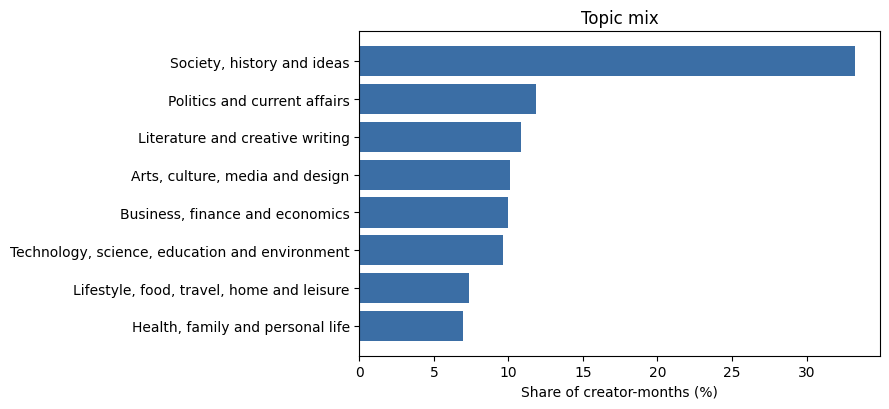

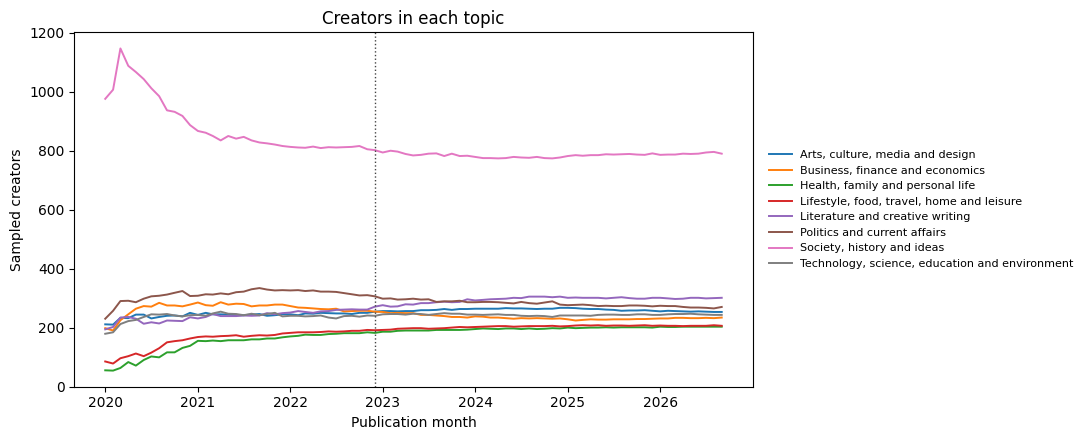

topic-months below the 150 floor: 20 of 648


,year_month,topic_family,eligible_candidate_creators,sampled_creators,topic_floor_shortfall
6,2020-01,"Health, family and personal life",55,55,95
7,2020-01,"Lifestyle, food, travel, home and leisure",85,85,65
14,2020-02,"Health, family and personal life",54,54,96
15,2020-02,"Lifestyle, food, travel, home and leisure",78,78,72
22,2020-03,"Health, family and personal life",63,63,87
23,2020-03,"Lifestyle, food, travel, home and leisure",96,96,54
30,2020-04,"Health, family and personal life",83,83,67
31,2020-04,"Lifestyle, food, travel, home and leisure",103,103,47
38,2020-05,"Health, family and personal life",71,71,79
39,2020-05,"Lifestyle, food, travel, home and leisure",112,112,38


In [27]:
topic_totals = (
    coverage.groupby("topic_family", as_index=False)["sampled_creators"]
    .sum()
    .sort_values("sampled_creators")
)
topic_totals["share_pct"] = 100 * topic_totals["sampled_creators"] / topic_totals["sampled_creators"].sum()

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(topic_totals["topic_family"], topic_totals["share_pct"], color="#3b6ea5")
ax.set_xlabel("Share of creator-months (%)")
ax.set_title("Topic mix")
fig.tight_layout()
plt.show()

wide = coverage.pivot(index="year_month", columns="topic_family", values="sampled_creators")
fig, ax = plt.subplots(figsize=(11, 4.5))
for name in wide.columns:
    ax.plot(wide.index, wide[name], lw=1.4, label=name)
ax.axvline(CUT, color="#444444", ls=":", lw=1)
ax.set_ylabel("Sampled creators")
ax.set_xlabel("Publication month")
ax.set_title("Creators in each topic")
ax.legend(frameon=False, fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout()
plt.show()

short = coverage.loc[coverage["topic_floor_shortfall"] > 0,
    ["year_month", "topic_family", "eligible_candidate_creators", "sampled_creators", "topic_floor_shortfall"]].copy()
short["year_month"] = short["year_month"].dt.strftime("%Y-%m")
print(f"topic-months below the 150 floor: {len(short)} of {len(coverage)}")
short


## Before and after December 2022

After the cut we're still taking 2,500 creators a month. The pool of people who posted is just a lot bigger, so we keep a smaller slice of it.


In [28]:
def block(df, label):
    full = df[~df["is_partial_month"]]
    return {
        "period": label,
        "months": int(len(df)),
        "mean eligible creators": int(round(df["eligible"].mean())),
        "mean sampled creators": int(round(df["sampled"].mean())),
        "mean kept %": round(df["kept_pct"].mean(), 1),
        "mean posts": int(round(full["unique_selected_texts"].mean())),
        "mean posts per creator": round(df["posts_per_creator"].mean(), 3),
    }

compare = pd.DataFrame([block(pre, "through Nov 2022"), block(post, "Dec 2022 onward")])
compare


,period,months,mean eligible creators,mean sampled creators,mean kept %,mean posts,mean posts per creator
0,through Nov 2022,35,7144,2480,45.1,5092,2.052
1,Dec 2022 onward,46,40273,2500,7.7,5124,2.044


## Stuff to flag when we write this up

Full months are about 2,500 creators and 5,100 posts, and every month's manifest passed validation. Big enough for a monthly series.

A few caveats:

1. 37,314 publications were still uncollected when the zip was frozen. Who counts as eligible can still change once those come in.
2. We kept the whole eligible pool in early 2020 and about 4% of it by 2026. A change in the monthly average can just be a change in who clears the cap.
3. We only keep 1–3 posts per creator-month, so this file can't tell us whether people published more after ChatGPT. Anything about style has to come from the post text.


## Do the same people come back?

Every month is a new draw. The creator-month files say who we kept, how many public posts they had, and how many of those we selected (3 at most).

24,744 creators show up somewhere across the 81 months. 3,793 of them appear at least once before December 2022 and at least once after. 10,389 are only on the early side, 10,562 only on the later side.


creators: 24,744
in exactly one month: 5,435
in all 81 months: 4
median months in the sample: 5


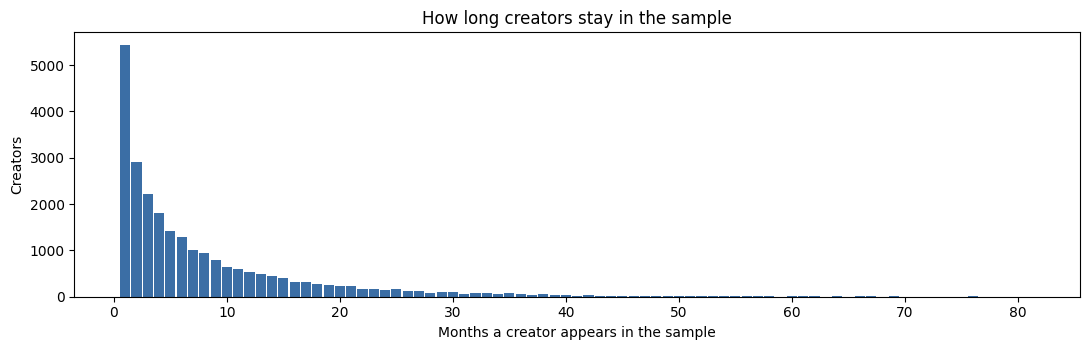

In [29]:
repeat = pd.read_csv(DATA / "creator_repeat.csv")
print(f"creators: {int(repeat['creators'].sum()):,}")
print(f"in exactly one month: {int(repeat.loc[repeat['months_in_sample']==1, 'creators'].sum()):,}")
print(f"in all 81 months: {int(repeat.loc[repeat['months_in_sample']==81, 'creators'].sum()):,}")
print(f"median months in the sample: {repeat.loc[repeat.index.repeat(repeat['creators']), 'months_in_sample'].median():.0f}")

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(repeat["months_in_sample"], repeat["creators"], color="#3b6ea5", width=0.9)
ax.set_xlabel("Months a creator appears in the sample")
ax.set_ylabel("Creators")
ax.set_title("How long creators stay in the sample")
fig.tight_layout()
plt.show()


## What they wrote vs what we kept

`qualifying_posts` is how many public posts they had that month. `selected_posts` is what actually landed in the sample. The median is 2 qualifying posts in every month, so the cap mostly hits the heavy posters. About a third of creator-months have 4 or more.


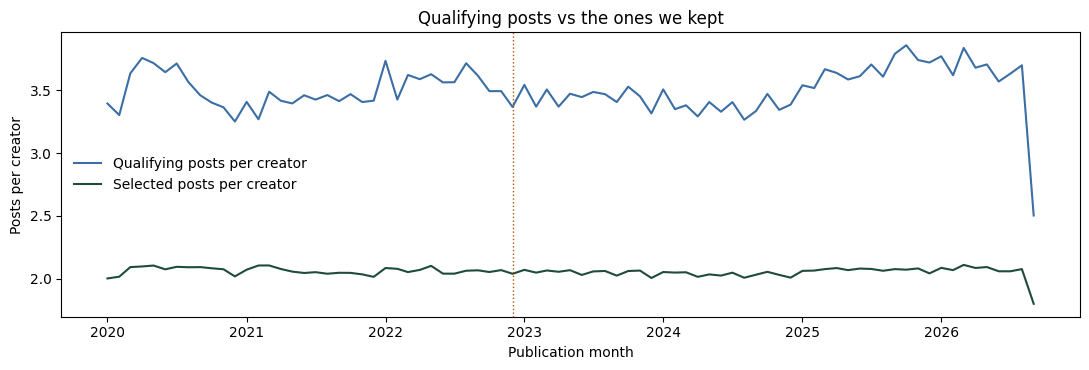

,period,qualifying per creator,selected per creator,share with 4+ qualifying posts %
0,through Nov 2022,3.507,2.064,32.5
1,Dec 2022 through Aug 2026,3.527,2.055,31.2


In [30]:
volume = pd.read_csv(DATA / "creator_month_volume.csv", parse_dates=["year_month"])
volume["qual_per_creator"] = volume["qualifying_posts"] / volume["sampled_creators"]
volume["sel_per_creator"] = volume["selected_posts"] / volume["sampled_creators"]
volume["share_4plus"] = 100 * volume["creators_with_4plus"] / volume["sampled_creators"]
volume["period"] = volume["year_month"].ge(CUT).map({False: "pre", True: "post"})

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(volume["year_month"], volume["qual_per_creator"], color="#3b6ea5", label="Qualifying posts per creator")
ax.plot(volume["year_month"], volume["sel_per_creator"], color="#1f4b3a", label="Selected posts per creator")
ax.axvline(CUT, color="#b45309", ls=":", lw=1)
ax.set_ylabel("Posts per creator")
ax.set_xlabel("Publication month")
ax.set_title("Qualifying posts vs the ones we kept")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

full = volume[volume["year_month"] < "2026-09-01"]
def vblock(df, label):
    return {
        "period": label,
        "qualifying per creator": round(df["qualifying_posts"].sum() / df["sampled_creators"].sum(), 3),
        "selected per creator": round(df["selected_posts"].sum() / df["sampled_creators"].sum(), 3),
        "share with 4+ qualifying posts %": round(100 * df["creators_with_4plus"].sum() / df["sampled_creators"].sum(), 1),
    }
pd.DataFrame([
    vblock(full[full["period"]=="pre"], "through Nov 2022"),
    vblock(full[full["period"]=="post"], "Dec 2022 through Aug 2026"),
])


## How long the posts are, and the likes

This is every `posts_meta.csv` in the zip: 413,252 posts. All of them are public. 407,063 are tagged English, and 6,189 have the language field blank.

Likes and comments were pulled in one pass, 21 September to 2 October 2026. A 2020 post had years longer to collect them than a 2026 post.


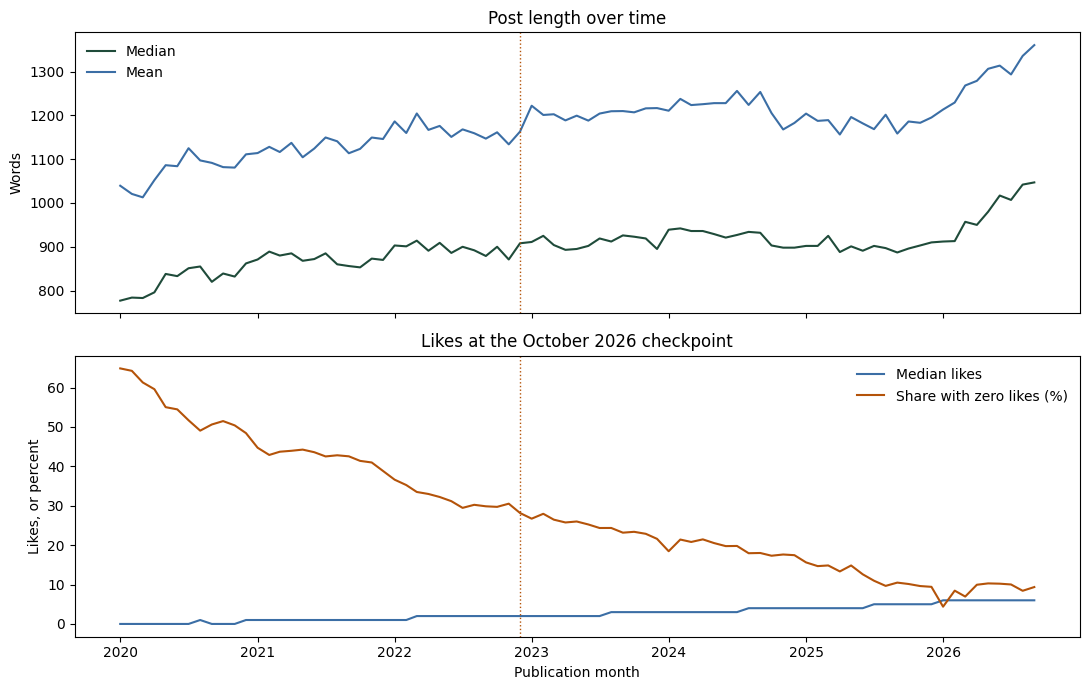

posts: 413,252
paywalled: 0
median words, 2020-01: 777
median words, 2022-11: 871
median words, 2026-08: 1042
zero-like share, 2020-01: 64.9%
zero-like share, 2026-08: 8.4%
median comments stays 0 through 2025-11 and is 1 from 2025-12


In [31]:
posts = pd.read_csv(DATA / "post_length_engagement.csv", parse_dates=["year_month"])
posts["zero_like_pct"] = 100 * posts["zero_likes"] / posts["posts"]
posts["zero_comment_pct"] = 100 * posts["zero_comments"] / posts["posts"]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(posts["year_month"], posts["median_words"], color="#1f4b3a", label="Median")
axes[0].plot(posts["year_month"], posts["mean_words"], color="#3b6ea5", label="Mean")
axes[0].axvline(CUT, color="#b45309", ls=":", lw=1)
axes[0].set_ylabel("Words")
axes[0].set_title("Post length over time")
axes[0].legend(frameon=False)

axes[1].plot(posts["year_month"], posts["median_likes"], color="#3b6ea5", label="Median likes")
axes[1].plot(posts["year_month"], posts["zero_like_pct"], color="#b45309", label="Share with zero likes (%)")
axes[1].axvline(CUT, color="#b45309", ls=":", lw=1)
axes[1].set_ylabel("Likes, or percent")
axes[1].set_xlabel("Publication month")
axes[1].set_title("Likes at the October 2026 checkpoint")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"posts: {int(posts['posts'].sum()):,}")
print(f"paywalled: {int(posts['paywalled'].sum())}")
print(f"median words, 2020-01: {int(posts.loc[posts['year_month']=='2020-01-01','median_words'].iloc[0])}")
print(f"median words, 2022-11: {int(posts.loc[posts['year_month']=='2022-11-01','median_words'].iloc[0])}")
print(f"median words, 2026-08: {int(posts.loc[posts['year_month']=='2026-08-01','median_words'].iloc[0])}")
print(f"zero-like share, 2020-01: {posts.loc[posts['year_month']=='2020-01-01','zero_like_pct'].iloc[0]:.1f}%")
print(f"zero-like share, 2026-08: {posts.loc[posts['year_month']=='2026-08-01','zero_like_pct'].iloc[0]:.1f}%")
print(f"median comments stays 0 through 2025-11 and is 1 from 2025-12")


## So far

Posts per month stay flat, and the underlying count is flat too: about 3.5 public posts per selected creator before December 2022 and about 3.5 after. The median writer is under the cap. About 32% of creator-months get trimmed from 4 or more posts down to 3.

Length is what actually moves. The median goes from 777 words in January 2020 to 871 in November 2022 and 1,042 in August 2026.

A within-writer comparison only has the 3,793 people on both sides of December 2022. The other 20,951 are on one side only.

Newer posts have more likes even with less time to collect them. The comment median stays at 0 until December 2025. Both are checkpoint totals, so they're a rough read on how a post was doing in the month it went up.

Style still needs the post text. That's about 2.9 GB.


## Did length bend in December 2022?

Comparing averages before and after will pick up a rise that was already happening. Here each full month is one point. The line has a slope through November 2022, a jump in December, and a new slope after that. September 2026 is only 17 days, so it's left out.

Fit twice: once on every selected post, once on the 3,793 creators we see on both sides.


In [32]:
import numpy as np

overlap = pd.read_csv(DATA / "overlap_length.csv", parse_dates=["year_month"])
paired = pd.read_csv(DATA / "overlap_paired.csv").iloc[0]

def broken_line(frame, ycol):
    d = frame[frame["year_month"] < "2026-09-01"].copy()
    d["t"] = (d["year_month"].dt.year - 2020) * 12 + (d["year_month"].dt.month - 1)
    cut = 35  # 2022-12
    d["post"] = (d["t"] >= cut).astype(float)
    d["t_post"] = np.maximum(d["t"] - cut, 0.0)
    X = np.column_stack([np.ones(len(d)), d["t"], d["post"], d["t_post"]])
    y = d[ycol].to_numpy(float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    dof = len(y) - X.shape[1]
    sigma2 = float(resid @ resid) / dof
    se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))
    d["fitted"] = X @ beta
    return d, beta, se

def report(label, beta, se):
    pre = beta[1]
    jump = beta[2]
    change = beta[3]
    post = pre + change
    return {
        "series": label,
        "pre slope, words per month": round(pre, 2),
        "post slope, words per month": round(post, 2),
        "change in slope": round(change, 2),
        "change / SE": round(change / se[3], 2),
        "level jump in Dec 2022": round(jump, 1),
        "jump / SE": round(jump / se[2], 2),
    }

all_fit, all_b, all_se = broken_line(posts, "median_words")
over_fit, over_b, over_se = broken_line(overlap, "median_words")
slope_table = pd.DataFrame([
    report("all selected posts", all_b, all_se),
    report("creators on both sides", over_b, over_se),
])
slope_table


,series,"pre slope, words per month","post slope, words per month",change in slope,change / SE,level jump in Dec 2022,jump / SE
0,all selected posts,2.89,1.04,-1.86,-3.36,-14.7,-1.19
1,creators on both sides,4.01,0.69,-3.31,-5.22,-2.9,-0.20


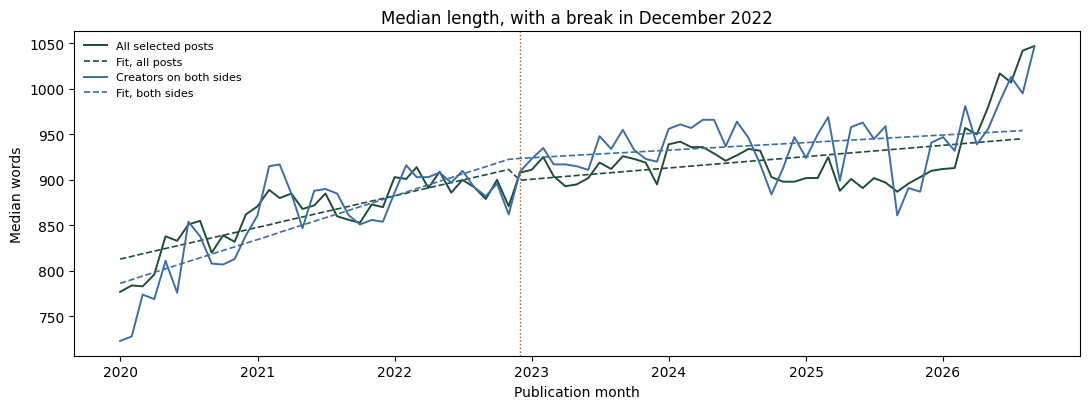

creators with posts on both sides: 3,793
their mean post length before Dec 2022: 1172 words
their mean post length from Dec 2022 on: 1262 words
median creator's change: 51 words
middle half of creator changes: -164 to 319 words


In [33]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(posts["year_month"], posts["median_words"], color="#1f4b3a", lw=1.4, label="All selected posts")
ax.plot(all_fit["year_month"], all_fit["fitted"], color="#1f4b3a", ls="--", lw=1.2, label="Fit, all posts")
ax.plot(overlap["year_month"], overlap["median_words"], color="#3b6ea5", lw=1.4, label="Creators on both sides")
ax.plot(over_fit["year_month"], over_fit["fitted"], color="#3b6ea5", ls="--", lw=1.2, label="Fit, both sides")
ax.axvline(CUT, color="#b45309", ls=":", lw=1)
ax.set_ylabel("Median words")
ax.set_xlabel("Publication month")
ax.set_title("Median length, with a break in December 2022")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

print(f"creators with posts on both sides: {int(paired['creators']):,}")
print(f"their mean post length before Dec 2022: {paired['mean_words_pre']:.0f} words")
print(f"their mean post length from Dec 2022 on: {paired['mean_words_post']:.0f} words")
print(f"median creator's change: {paired['median_creator_diff']:.0f} words")
print(f"middle half of creator changes: {paired['p25_creator_diff']:.0f} to {paired['p75_creator_diff']:.0f} words")
